TP Final Big Data: Random Forest sobre riesgo crediticio en Taiwan <https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients>
*   Integrantes: Agustin Esteves, Ignacio Del Bianco y Bruno Petruzzi
*   Profesor: Santiago Nuñez Rimedio



In [ ]:
# Importando las librerias
!pip install highlight_text
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from highlight_text import ax_text, fig_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import numpy as np
from sklearn.preprocessing import LabelEncoder
!pip install highlight_text
import joblib

# Importando la base de datos
from google.colab import drive

drive.mount("/content/drive")

df_taiwan = pd.read_excel('/content/drive/MyDrive/Big Data/Base - taiwan.xls', header=1)

Mounted at /content/drive


## Analisis Exploratorio de Datos

In [ ]:
df_taiwan

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [ ]:
# Informacion general

df_taiwan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [ ]:
# Verificando existencia de valores nulos

df_taiwan.isnull().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


In [ ]:
# Eliminar primer columna

df_taiwan = df_taiwan.drop("ID", axis=1)

In [ ]:
# Renombrando las columnas

df_taiwan.columns = ["Monto", "Genero", "Educacion", "Estado Civil", "Edad", "H1", "H2", "H3", "H4", "H5", "H6", "MC1", "MC2", "MC3", "MC4", "MC5", "MC6", "MP1", "MP2", "MP3", "MP4", "MP5", "MP6", "Default"]

In [ ]:
# Resultado de la limpieza de la base

df_taiwan

,Monto,Genero,Educacion,Estado Civil,Edad,H1,H2,H3,H4,H5,...,MC4,MC5,MC6,MP1,MP2,MP3,MP4,MP5,MP6,Default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,80000,1,3,1,41,1,-1,0,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [ ]:
df_taiwan["Educacion"].value_counts()

,count
Educacion,
2,14030
1,10585
3,4917
5,280
4,123
6,51
0,14


In [ ]:
df_taiwan["Estado Civil"].value_counts()

,count
Estado Civil,
2,15964
1,13659
3,323
0,54


In [ ]:
df_taiwan["H1"].value_counts()

,count
H1,
0,14737
-1,5686
1,3688
-2,2759
2,2667
3,322
4,76
5,26
8,19


In [ ]:
df_taiwan = df_taiwan[df_taiwan['Educacion'].isin([1, 2, 3, 4])]
display(df_taiwan.head())

,Monto,Genero,Educacion,Estado Civil,Edad,H1,H2,H3,H4,H5,...,MC4,MC5,MC6,MP1,MP2,MP3,MP4,MP5,MP6,Default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
df_taiwan = df_taiwan[df_taiwan['Estado Civil'].isin([1, 2, 3])]
display(df_taiwan.head())

,Monto,Genero,Educacion,Estado Civil,Edad,H1,H2,H3,H4,H5,...,MC4,MC5,MC6,MP1,MP2,MP3,MP4,MP5,MP6,Default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
H_cols = ["H1", "H2", "H3", "H4", "H5", "H6"]
allowed_values = [-1, 1, 2, 3, 4, 5, 6, 7, 8, 9]

for col in H_cols:
    df_taiwan = df_taiwan[df_taiwan[col].isin(allowed_values)]

display(df_taiwan.head())

,Monto,Genero,Educacion,Estado Civil,Edad,H1,H2,H3,H4,H5,...,MC4,MC5,MC6,MP1,MP2,MP3,MP4,MP5,MP6,Default
11,260000,2,1,2,51,-1,-1,-1,-1,-1,...,8517,22287,13668,21818,9966,8583,22301,0,3640,0
21,120000,2,2,1,39,-1,-1,-1,-1,-1,...,0,632,316,316,316,0,632,316,0,1
28,50000,2,3,1,47,-1,-1,-1,-1,-1,...,2040,30430,257,3415,3421,2044,30430,257,0,0
30,230000,2,1,2,27,-1,-1,-1,-1,-1,...,15339,14307,36923,17270,13281,15339,14307,37292,0,0
48,380000,1,2,2,32,-1,-1,-1,-1,-1,...,32018,11849,11873,21540,15138,24677,11851,11875,8251,0


In [ ]:
# Reset del indice
df_taiwan.reset_index(drop=True, inplace=True)

In [ ]:
df_taiwan

,Monto,Genero,Educacion,Estado Civil,Edad,H1,H2,H3,H4,H5,...,MC4,MC5,MC6,MP1,MP2,MP3,MP4,MP5,MP6,Default
0,260000,2,1,2,51,-1,-1,-1,-1,-1,...,8517,22287,13668,21818,9966,8583,22301,0,3640,0
1,120000,2,2,1,39,-1,-1,-1,-1,-1,...,0,632,316,316,316,0,632,316,0,1
2,50000,2,3,1,47,-1,-1,-1,-1,-1,...,2040,30430,257,3415,3421,2044,30430,257,0,0
3,230000,2,1,2,27,-1,-1,-1,-1,-1,...,15339,14307,36923,17270,13281,15339,14307,37292,0,0
4,380000,1,2,2,32,-1,-1,-1,-1,-1,...,32018,11849,11873,21540,15138,24677,11851,11875,8251,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4025,360000,1,2,1,45,-1,-1,-1,-1,-1,...,836,986,986,836,836,836,986,986,611,0
4026,130000,1,3,1,45,-1,-1,-1,-1,-1,...,2756,1585,1215,1826,2831,2756,1585,1215,2402,1
4027,40000,1,2,2,47,2,2,3,2,2,...,51259,47151,46934,4000,0,2000,0,3520,0,1
4028,210000,1,2,1,34,3,2,2,2,2,...,2500,2500,2500,0,0,0,0,0,0,1


In [ ]:
df_taiwan[["Genero", "Educacion", "Estado Civil"]] = df_taiwan[["Genero", "Educacion", "Estado Civil"]].astype(str)

In [ ]:
df_taiwan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4030 entries, 0 to 4029
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Monto         4030 non-null   int64 
 1   Genero        4030 non-null   object
 2   Educacion     4030 non-null   object
 3   Estado Civil  4030 non-null   object
 4   Edad          4030 non-null   int64 
 5   H1            4030 non-null   int64 
 6   H2            4030 non-null   int64 
 7   H3            4030 non-null   int64 
 8   H4            4030 non-null   int64 
 9   H5            4030 non-null   int64 
 10  H6            4030 non-null   int64 
 11  MC1           4030 non-null   int64 
 12  MC2           4030 non-null   int64 
 13  MC3           4030 non-null   int64 
 14  MC4           4030 non-null   int64 
 15  MC5           4030 non-null   int64 
 16  MC6           4030 non-null   int64 
 17  MP1           4030 non-null   int64 
 18  MP2           4030 non-null   int64 
 19  MP3   

In [ ]:
df_taiwan.describe()

,Monto,Edad,H1,H2,H3,H4,H5,H6,MC1,MC2,...,MC4,MC5,MC6,MP1,MP2,MP3,MP4,MP5,MP6,Default
count,4030.000000,4030.000000,4030.000000,4030.000000,4030.000000,4030.000000,4030.000000,4030.000000,4030.000000,4030.000000,...,4030.000000,4030.000000,4030.000000,4030.000000,4030.000000,4030.000000,4030.000000,4030.000000,4030.000000,4030.000000
mean,171657.568238,36.522084,0.183871,0.289578,0.322581,0.287593,0.246154,0.252605,22090.757320,22256.289826,...,22618.342680,22590.346402,22701.868983,4654.058065,4609.700000,4719.065757,4547.375186,4605.919851,4590.067990,0.356328
std,125943.771452,9.180649,1.575340,1.681448,1.738462,1.802048,1.780999,1.747022,44288.455981,44328.658159,...,44947.085387,44523.318928,45530.500711,10882.895838,11979.728987,13410.749346,11093.974616,13538.101017,14952.875407,0.478973
min,10000.000000,21.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-4316.000000,-24704.000000,...,-3903.000000,-3876.000000,-339603.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,60000.000000,29.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,931.000000,856.000000,...,832.250000,846.000000,780.000000,316.000000,316.000000,316.000000,330.500000,98.000000,0.000000,0.000000
50%,150000.000000,35.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,4405.000000,4414.000000,...,4180.000000,4087.000000,4162.000000,1600.000000,1595.000000,1443.000000,1443.500000,1228.000000,1048.000000,0.000000
75%,240000.000000,43.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,22234.000000,22758.750000,...,22900.500000,23345.500000,23999.250000,4411.750000,4395.250000,4200.000000,4100.000000,4000.000000,3710.000000,1.000000
max,740000.000000,72.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,581775.000000,572677.000000,...,486776.000000,503914.000000,527711.000000,187206.000000,302961.000000,417588.000000,193712.000000,303512.000000,345293.000000,1.000000


## Visualizacion de Datos

In [ ]:
tabla1 = pd.crosstab(df_taiwan["Genero"], df_taiwan["Default"])
tabla1

Default,0,1
Genero,,
1,1002,643
2,1592,793


In [ ]:
tabla2 = pd.crosstab(df_taiwan["Educacion"], df_taiwan["Default"])
tabla2

Default,0,1
Educacion,,
1,1207,476
2,1002,711
3,375,249
4,10,0


In [ ]:
tabla3 = pd.crosstab(df_taiwan["Estado Civil"], df_taiwan["Default"])
tabla3

Default,0,1
Estado Civil,,
1,1348,728
2,1229,691
3,17,17


In [ ]:
df_graf = pd.DataFrame({
    "Clase": ["Hombre", "Mujer", "Casado", "Soltero", "Posgrado", "Universidad", "Secundario"],
    "Casos": [1645, 2385, 2076, 1920, 1683, 1713, 624],
    "Moroso": [643, 793, 728, 691, 476, 711, 249],
    "No Moroso": [1002, 1592, 1348, 1229, 1207, 1002, 375]
})

df_graf

,Clase,Casos,Moroso,No Moroso
0,Hombre,1645,643,1002
1,Mujer,2385,793,1592
2,Casado,2076,728,1348
3,Soltero,1920,691,1229
4,Posgrado,1683,476,1207
5,Universidad,1713,711,1002
6,Secundario,624,249,375


In [ ]:
df_graf['Moroso'] = df_graf['Moroso'] / df_graf['Casos']
df_graf['No Moroso'] = df_graf['No Moroso'] / df_graf['Casos']
df_graf.sort_values(by='Casos', inplace=True)
df_graf.reset_index(drop=True, inplace=True)
df_graf

,Clase,Casos,Moroso,No Moroso
0,Secundario,624,0.399038,0.600962
1,Hombre,1645,0.390881,0.609119
2,Posgrado,1683,0.282828,0.717172
3,Universidad,1713,0.415061,0.584939
4,Soltero,1920,0.359896,0.640104
5,Casado,2076,0.350674,0.649326
6,Mujer,2385,0.332495,0.667505


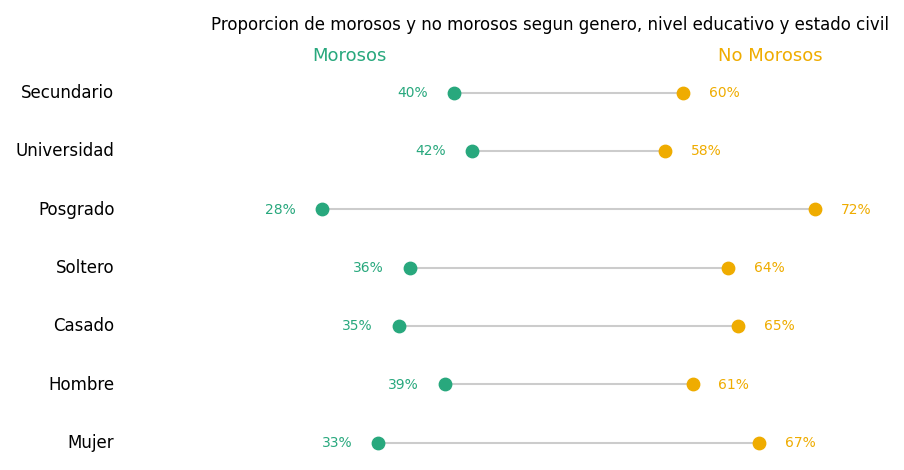

In [ ]:
# Definir un orden específico
orden_personalizado = ['Mujer', 'Hombre', 'Casado', 'Soltero', 'Posgrado', 'Universidad', 'Secundario']

df_graf['Clase'] = pd.Categorical(df_graf['Clase'], categories=orden_personalizado, ordered=True)
df_graf = df_graf.sort_values('Clase')

fig, ax = plt.subplots(figsize=(7,5))

color_No_Moroso, color_Moroso = "#EFAC00", "#28A87D"

# Lineas Horizontales
my_range = range(len(df_graf)) # Use the length of the dataframe for the range
ax.hlines(y=my_range, xmin=df_graf['No Moroso'], xmax=df_graf['Moroso'], color='grey', alpha=0.4)

# Puntos
ax.scatter(df_graf['No Moroso'], my_range, color=color_No_Moroso, zorder=2, s=80)
ax.scatter(df_graf['Moroso'], my_range, color=color_Moroso, zorder=2, s=80)

# Agregando las clases
n = len(df_graf)
for i in range(len(df_graf)):

    # No Morosos
    losses = df_graf['No Moroso'].iloc[i]
    ax_text(
        losses+0.05, i,
        f"{losses*100:.0f}%",
        ha='right', va='center',
        color=color_No_Moroso,
        weight="light"
    )

    # Morosos
    wins = df_graf['Moroso'].iloc[i]
    ax_text(
        wins-0.05, i,
        f"{wins*100:.0f}%",
        ha='left', va='center',
        color=color_Moroso,
        weight="light"
    )

    # Nombres de las Clases
    team_name = df_graf['Clase'].iloc[i]
    ax_text(0.1, i,
            f"{team_name}",
            ha='right', va='center',
            color="black",
            weight="light",
            size=12
    )

# titulo
text = "Proporcion de morosos y no morosos segun genero, nivel educativo y estado civil"
fig_text(
    0.002, 1,
    text,
    fontsize=12
)

# Leyenda
text = 'Morosos'
fig_text(
    0.2, 0.92,
    text,
    fontsize=13,
    ha='center', va='center',
    color=color_Moroso
)
text = 'No Morosos'
fig_text(
    0.8, 0.92,
    text,
    fontsize=13,
    ha='center', va='center',
    color=color_No_Moroso
)


# remove axis
ax.set_axis_off()


plt.show()

In [ ]:
df_taiwan.columns


Index(['Monto', 'Genero', 'Educacion', 'Estado Civil', 'Edad', 'H1', 'H2',
       'H3', 'H4', 'H5', 'H6', 'MC1', 'MC2', 'MC3', 'MC4', 'MC5', 'MC6', 'MP1',
       'MP2', 'MP3', 'MP4', 'MP5', 'MP6', 'Default'],
      dtype='object')

In [ ]:
corr_matrix = df_taiwan[['Monto', 'Genero', 'Educacion', 'Estado Civil', 'Edad', 'H1', 'H2',
       'H3', 'H4', 'H5', 'H6', 'MC1', 'MC2', 'MC3', 'MC4', 'MC5', 'MC6', 'MP1',
       'MP2', 'MP3', 'MP4', 'MP5', 'MP6']].corr()
corr_matrix

,Monto,Genero,Educacion,Estado Civil,Edad,H1,H2,H3,H4,H5,...,MC3,MC4,MC5,MC6,MP1,MP2,MP3,MP4,MP5,MP6
Monto,1.000000,-0.027035,-0.263632,-0.140972,0.209705,-0.376119,-0.425526,-0.421898,-0.419223,-0.430223,...,0.033111,0.040800,0.027148,0.036312,0.253652,0.248872,0.253582,0.274045,0.252139,0.207691
Genero,-0.027035,1.000000,0.024525,-0.000509,-0.092132,-0.060428,-0.068360,-0.075909,-0.085714,-0.088759,...,-0.041714,-0.049631,-0.045581,-0.045575,0.003940,0.021709,-0.009136,0.009378,0.003531,0.014419
Educacion,-0.263632,0.024525,1.000000,-0.151455,0.165835,0.177662,0.190868,0.192218,0.198022,0.196666,...,0.026542,0.024659,0.029166,0.024546,-0.069984,-0.086529,-0.085348,-0.084376,-0.070385,-0.081085
Estado Civil,-0.140972,-0.000509,-0.151455,1.000000,-0.470870,0.046192,0.055236,0.064034,0.065655,0.062757,...,-0.011063,-0.011083,-0.014054,-0.013655,-0.039123,-0.023473,-0.028080,-0.042161,-0.027188,0.008348
Edad,0.209705,-0.092132,0.165835,-0.470870,1.000000,-0.059840,-0.073933,-0.065217,-0.067543,-0.067063,...,0.019000,0.017461,0.019296,0.023811,0.068111,0.063784,0.054081,0.080145,0.079010,0.012006
H1,-0.376119,-0.060428,0.177662,0.046192,-0.059840,1.000000,0.804464,0.771424,0.777421,0.770925,...,0.451063,0.444081,0.450014,0.434643,-0.143682,-0.134319,-0.129775,-0.147715,-0.113220,-0.099463
H2,-0.425526,-0.068360,0.190868,0.055236,-0.073933,0.804464,1.000000,0.838693,0.803352,0.803428,...,0.466499,0.458529,0.468691,0.453836,-0.187101,-0.135253,-0.142432,-0.153977,-0.122674,-0.098332
H3,-0.421898,-0.075909,0.192218,0.064034,-0.065217,0.771424,0.838693,1.000000,0.872454,0.857584,...,0.421245,0.419715,0.429643,0.415472,-0.147717,-0.164249,-0.132391,-0.153489,-0.128450,-0.110888
H4,-0.419223,-0.085714,0.198022,0.065655,-0.067543,0.777421,0.803352,0.872454,1.000000,0.935028,...,0.403702,0.395974,0.407542,0.395213,-0.154426,-0.126835,-0.155721,-0.151077,-0.136464,-0.106668
H5,-0.430223,-0.088759,0.196666,0.062757,-0.067063,0.770925,0.803428,0.857584,0.935028,1.000000,...,0.405272,0.404901,0.412732,0.401206,-0.148336,-0.128306,-0.129812,-0.168207,-0.137591,-0.108123


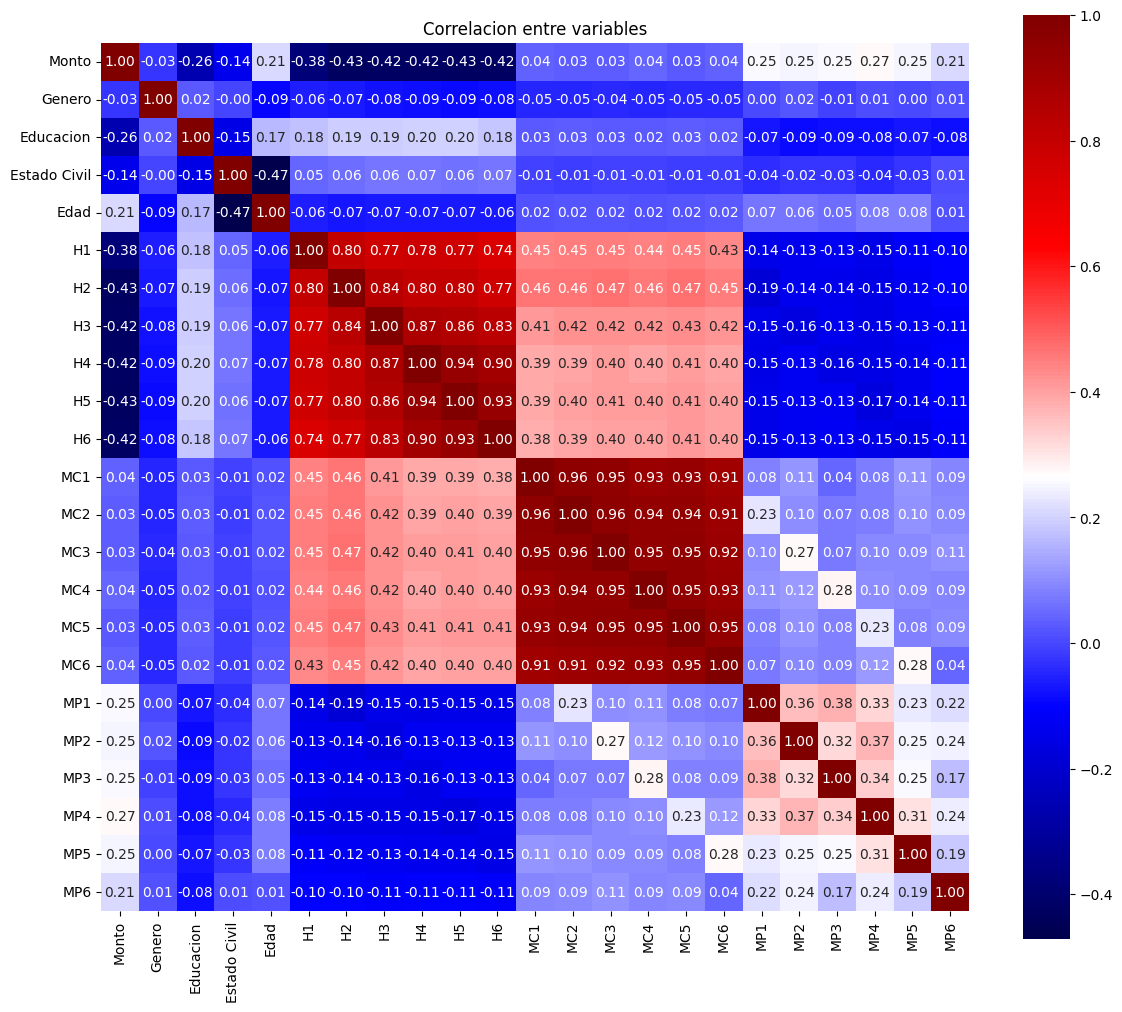

In [ ]:
plt.figure(figsize=(14, 12))

# Use seaborn's heatmap function for better visualization
sns.heatmap(corr_matrix, annot=True, cmap='seismic', fmt=".2f", square=True)

# titulo del grafico
plt.title('Correlacion entre variables')

# Mostrar el grafico
plt.show()

<Axes: >

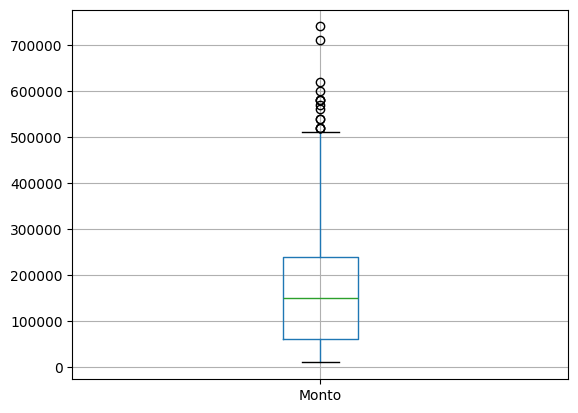

In [ ]:
df_taiwan[["Monto"]].boxplot()

<Axes: >

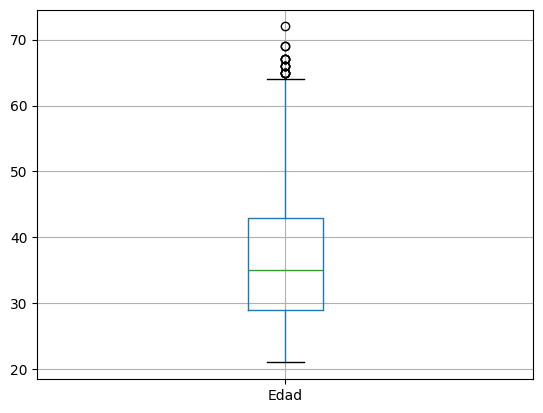

In [ ]:
df_taiwan[["Edad"]].boxplot()

<Axes: >

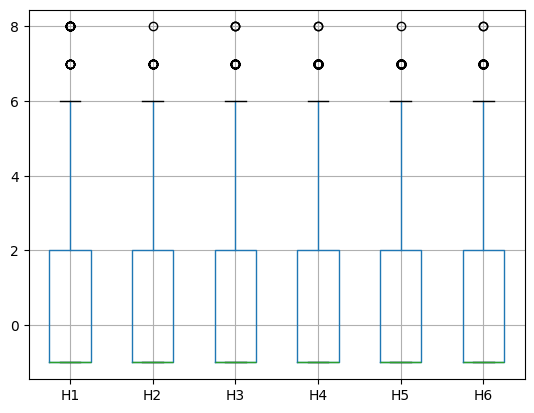

In [ ]:
df_taiwan[['H1', 'H2','H3', 'H4', 'H5', 'H6']].boxplot()

<Axes: >

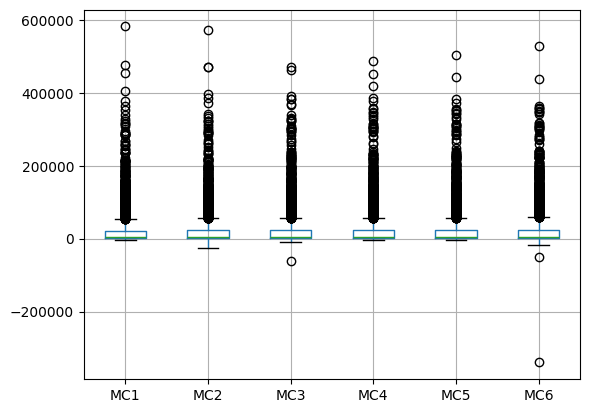

In [ ]:
df_taiwan[['MC1', 'MC2', 'MC3', 'MC4', 'MC5', 'MC6']].boxplot()

<Axes: >

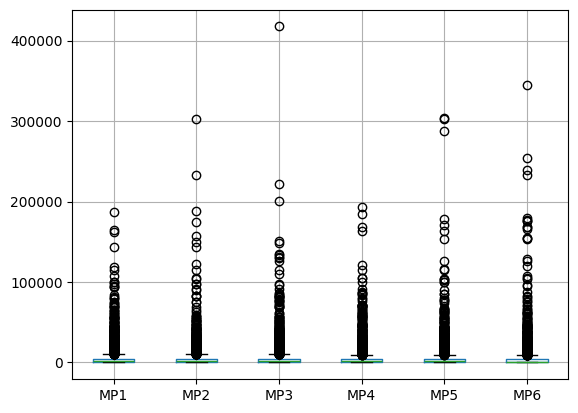

In [ ]:
df_taiwan[['MP1','MP2', 'MP3', 'MP4', 'MP5', 'MP6']].boxplot()

In [ ]:
# Limpieza de outliers, criterio del percentil 95%
df_taiwan_outliers = df_taiwan.copy()

cols_filtrar = ['Monto', 'MC1', 'MC2', 'MC3', 'MC4', 'MC5', 'MC6',
                'MP1', 'MP2', 'MP3', 'MP4', 'MP5', 'MP6']

for col in cols_filtrar:
    Q95 = df_taiwan_outliers[col].quantile(0.95)
    df_taiwan_outliers = df_taiwan_outliers[df_taiwan_outliers[col] <= Q95]

In [ ]:
df_taiwan_outliers.describe()

,Monto,Edad,H1,H2,H3,H4,H5,H6,MC1,MC2,...,MC4,MC5,MC6,MP1,MP2,MP3,MP4,MP5,MP6,Default
count,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,...,2069.00000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000,2069.000000
mean,141338.811020,36.189464,-0.006767,0.091832,0.170130,0.154664,0.115031,0.115031,4819.380377,4491.813436,...,4391.38231,4386.486709,4311.711455,1521.276945,1484.273079,1327.170130,1240.393910,1174.757371,1073.487192,0.352827
std,102705.169227,9.350931,1.483941,1.602487,1.772631,1.927169,1.907511,1.865474,7342.221479,6564.937805,...,6594.63135,6651.501228,6638.800937,2188.256799,2058.222183,1794.475564,1578.447789,1573.239695,1489.591424,0.477965
min,10000.000000,21.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-2159.000000,-1624.000000,...,-1170.00000,-510.000000,-2695.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,29.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,450.000000,396.000000,...,390.00000,396.000000,390.000000,0.000000,4.000000,0.000000,150.000000,0.000000,0.000000,0.000000
50%,130000.000000,35.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1626.000000,1473.000000,...,1358.00000,1326.000000,1261.000000,676.000000,651.000000,631.000000,661.000000,540.000000,466.000000,0.000000
75%,210000.000000,43.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,5770.000000,5344.000000,...,4644.00000,4274.000000,4414.000000,2000.000000,2000.000000,1806.000000,1652.000000,1526.000000,1463.000000,1.000000
max,430000.000000,67.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,94125.000000,66741.000000,...,31539.00000,29779.000000,27404.000000,15000.000000,11869.000000,10040.000000,8362.000000,7777.000000,7600.000000,1.000000


## **Construcción del modelo restringido (sin outliers)**

In [ ]:
# Definicion de variables

Y = df_taiwan_outliers["Default"]
X = df_taiwan_outliers[["Monto", "Genero", "Educacion", "Estado Civil", "Edad", "H1", "H2", "H3", "H4", "H5", "H6", "MC1", "MC2", "MC3", "MC4", "MC5", "MC6", "MP1", "MP2", "MP3", "MP4", "MP5", "MP6"]]

In [ ]:
# transformacion de variables categoricas

X = pd.get_dummies(X)

X

,Monto,Edad,H1,H2,H3,H4,H5,H6,MC1,MC2,...,MP6,Genero_1,Genero_2,Educacion_1,Educacion_2,Educacion_3,Educacion_4,Estado Civil_1,Estado Civil_2,Estado Civil_3
1,120000,39,-1,-1,-1,-1,-1,-1,316,316,...,0,False,True,False,True,False,False,True,False,False
5,200000,34,-1,3,2,2,2,2,1587,1098,...,0,False,True,True,False,False,False,False,True,False
7,210000,30,2,-1,-1,-1,-1,-1,300,300,...,909,False,True,True,False,False,False,False,True,False
8,80000,31,-1,-1,-1,-1,-1,-1,780,0,...,390,True,False,True,False,False,False,False,True,False
10,200000,32,-1,-1,-1,-1,2,-1,9076,5787,...,1395,False,True,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4021,210000,45,-1,-1,-1,-1,-1,-1,1792,4339,...,3912,True,False,False,True,False,False,True,False,False
4023,50000,37,-1,-1,2,2,-1,-1,3057,3427,...,0,True,False,False,False,True,False,True,False,False
4025,360000,45,-1,-1,-1,-1,-1,-1,18552,836,...,611,True,False,False,True,False,False,True,False,False
4026,130000,45,-1,-1,-1,-1,-1,-1,1475,1826,...,2402,True,False,False,False,True,False,True,False,False


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2069 entries, 1 to 4028
Data columns (total 29 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Monto           2069 non-null   int64
 1   Edad            2069 non-null   int64
 2   H1              2069 non-null   int64
 3   H2              2069 non-null   int64
 4   H3              2069 non-null   int64
 5   H4              2069 non-null   int64
 6   H5              2069 non-null   int64
 7   H6              2069 non-null   int64
 8   MC1             2069 non-null   int64
 9   MC2             2069 non-null   int64
 10  MC3             2069 non-null   int64
 11  MC4             2069 non-null   int64
 12  MC5             2069 non-null   int64
 13  MC6             2069 non-null   int64
 14  MP1             2069 non-null   int64
 15  MP2             2069 non-null   int64
 16  MP3             2069 non-null   int64
 17  MP4             2069 non-null   int64
 18  MP5             2069 non-null   i

In [ ]:
print(len(X.columns))

29


In [ ]:
Y.value_counts()

,count
Default,
0,1339
1,730


In [ ]:
# Definimos el test-train split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [ ]:
modelo_outliers = RandomForestClassifier(random_state=42)

param_grid1 = {
    "n_estimators": [200, 300],
    "max_depth": [8, 10, 12],
    "max_features": ['sqrt', 'log2', 0.3],
    "min_samples_split": [10, 20],
    "min_samples_leaf": [5, 10, 15],
    "class_weight": [
        'balanced',
        {0: 1, 1: 3},
        {0: 1, 1: 4}
    ]
}

modelo_outliers_grid = GridSearchCV(estimator=modelo_outliers, param_grid=param_grid1, cv=5, n_jobs=-1, scoring="recall")

modelo_outliers_grid.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced', {0: 1, 1: 3},
                                          {0: 1, 1: 4}],
                         'max_depth': [8, 10, 12],
                         'max_features': ['sqrt', 'log2', 0.3],
                         'min_samples_leaf': [5, 10, 15],
                         'min_samples_split': [10, 20],
                         'n_estimators': [200, 300]},
             scoring='recall')

In [ ]:
rf_outliers_best = modelo_outliers_grid.best_estimator_

Y_true = Y_test
Y_pred = rf_outliers_best.predict(X_test)

recall = recall_score(Y_test, Y_pred)

print(f"Recall del mejor estimador en el conjunto de testeo SIN OUTLIERS: {recall}")

Recall del mejor estimador en el conjunto de testeo SIN OUTLIERS: 0.7808219178082192


In [ ]:
# Define StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Utilizamos el cross_val_score con el mejor estimador obtenido del GridSearchCV + StratifiedKFold
# Usamos la metrica recall para evaluar performance del modelo sobre la clase minoritaria (morosos)

recall_scores = cross_val_score(rf_outliers_best, X, Y, cv=skf, scoring='recall', n_jobs=-1)

print("Recall scores for each fold:", recall_scores)
print("Mean recall score:", recall_scores.mean())

Recall scores for each fold: [0.7739726  0.76027397 0.78767123 0.82876712 0.83561644]
Mean recall score: 0.7972602739726027


In [ ]:
# Matriz de Confusion

print(classification_report(Y_test, Y_pred))
print("Matriz de confusión:")
print(confusion_matrix(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.84      0.62      0.71       268
           1       0.53      0.78      0.63       146

    accuracy                           0.68       414
   macro avg       0.68      0.70      0.67       414
weighted avg       0.73      0.68      0.68       414

Matriz de confusión:
[[166 102]
 [ 32 114]]


## **Construcción del Modelo Completo**

In [ ]:
# Definicion de Variables

y = df_taiwan["Default"]
x = df_taiwan[["Monto", "Genero", "Educacion", "Estado Civil", "Edad", "H1", "H2", "H3", "H4", "H5", "H6", "MC1", "MC2", "MC3", "MC4", "MC5", "MC6", "MP1", "MP2", "MP3", "MP4", "MP5", "MP6"]]

In [ ]:
# Obtencion de variables categoricas

x = pd.get_dummies(x)

x

,Monto,Edad,H1,H2,H3,H4,H5,H6,MC1,MC2,...,MP6,Genero_1,Genero_2,Educacion_1,Educacion_2,Educacion_3,Educacion_4,Estado Civil_1,Estado Civil_2,Estado Civil_3
0,260000,51,-1,-1,-1,-1,-1,2,12261,21670,...,3640,False,True,True,False,False,False,False,True,False
1,120000,39,-1,-1,-1,-1,-1,-1,316,316,...,0,False,True,False,True,False,False,True,False,False
2,50000,47,-1,-1,-1,-1,-1,-1,650,3415,...,0,False,True,False,False,True,False,True,False,False
3,230000,27,-1,-1,-1,-1,-1,-1,16646,17265,...,0,False,True,True,False,False,False,False,True,False
4,380000,32,-1,-1,-1,-1,-1,-1,22401,21540,...,8251,True,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4025,360000,45,-1,-1,-1,-1,-1,-1,18552,836,...,611,True,False,False,True,False,False,True,False,False
4026,130000,45,-1,-1,-1,-1,-1,-1,1475,1826,...,2402,True,False,False,False,True,False,True,False,False
4027,40000,47,2,2,3,2,2,2,52358,54892,...,0,True,False,False,True,False,False,False,True,False
4028,210000,34,3,2,2,2,2,2,2500,2500,...,0,True,False,False,True,False,False,True,False,False


In [ ]:
y.value_counts()

,count
Default,
0,2594
1,1436


In [ ]:
# Definimos el train-test split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
modelo = RandomForestClassifier(random_state=42)

grilla = {
    "n_estimators": [200, 300],
    "max_depth": [8, 10, 12],
    "max_features": ['sqrt', 'log2', 0.3],
    "min_samples_split": [10, 20],
    "min_samples_leaf": [5, 10, 15],
    "class_weight": [
        'balanced',
        {0: 1, 1: 3},
        {0: 1, 1: 4}
    ]
}

modelo_grid = GridSearchCV(estimator=modelo, param_grid=grilla, cv=5, n_jobs=-1, scoring="recall")

modelo_grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced', {0: 1, 1: 3},
                                          {0: 1, 1: 4}],
                         'max_depth': [8, 10, 12],
                         'max_features': ['sqrt', 'log2', 0.3],
                         'min_samples_leaf': [5, 10, 15],
                         'min_samples_split': [10, 20],
                         'n_estimators': [200, 300]},
             scoring='recall')

In [ ]:
rf_best = modelo_grid.best_estimator_

y_true = y_test
y_pred = rf_best.predict(x_test)

recall_original = recall_score(y_test, y_pred)

print(f"Recall del mejor estimador en el conjunto de testeo ORIGINAL: {recall_original}")

Recall del mejor estimador en el conjunto de testeo ORIGINAL: 0.8362369337979094


In [ ]:
# Define StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Utilizamos el cross_val_score con el mejor estimador obtenido del GridSearchCV + StratifiedKFold
# Usamos la metrica recall para evaluar performance del modelo sobre la clase minoritaria (morosos)

recall_scores = cross_val_score(rf_best, x, y, cv=skf, scoring='recall', n_jobs=-1)

print("Recall scores for each fold:", recall_scores)
print("Mean recall score:", recall_scores.mean())

Recall scores for each fold: [0.83623693 0.8466899  0.80836237 0.80487805 0.83333333]
Mean recall score: 0.8259001161440185


In [ ]:
print(classification_report(y_test, y_pred))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.62      0.72       519
           1       0.55      0.84      0.66       287

    accuracy                           0.70       806
   macro avg       0.71      0.73      0.69       806
weighted avg       0.76      0.70      0.70       806

Matriz de confusión:
[[321 198]
 [ 47 240]]


In [ ]:
modelo_grid.best_estimator_

RandomForestClassifier(class_weight={0: 1, 1: 4}, max_depth=8,
                       max_features='log2', min_samples_leaf=15,
                       min_samples_split=10, n_estimators=200, random_state=42)

In [ ]:
#Guardamos el modelo completo ya que tuvo mejor desempeño que el modelo sin outliers.
joblib.dump(modelo_grid.best_estimator_, '/content/drive/MyDrive/Big Data/rf_taiwan_grid.joblib')

['/content/drive/MyDrive/Big Data/rf_taiwan_grid.joblib']

## **Analisis de importancia de las features**

In [ ]:
importances = rf_best.feature_importances_
feature_names = x.columns
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)
print(feature_importance_df.head(10))

   feature  importance
6       H5    0.111882
3       H2    0.110243
5       H4    0.077663
7       H6    0.072661
2       H1    0.064821
4       H3    0.050741
9      MC2    0.047536
14     MP1    0.046367
16     MP3    0.045831
17     MP4    0.042249


In [ ]:
feature_importance_df

,feature,importance
6,H5,0.111882
3,H2,0.110243
5,H4,0.077663
7,H6,0.072661
2,H1,0.064821
4,H3,0.050741
9,MC2,0.047536
14,MP1,0.046367
16,MP3,0.045831
17,MP4,0.042249


In [ ]:
# Reset del indice
feature_importance_df.reset_index(drop=True, inplace=True)

In [ ]:
mapeo_nombres = {
    'Genero_1': 'Hombre',
    'Genero_2': 'Mujer',
    "Educacion_1" : "Posgrado",
    "Educacion_2" : "Universidad",
    "Educacion_3" : "Secundario",
    "Educacion_4" : "Otro nivel educativo",
    "Estado Civil_1" : "Casado",
    "Estado Civil_2" : "Soltero",
    "Estado Civil_3" : "Otro Estado Civil"
}

feature_importance_df['feature'].replace(mapeo_nombres, inplace=True)

/tmp/ipython-input-60-3385313081.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  feature_importance_df['feature'].replace(mapeo_nombres, inplace=True)


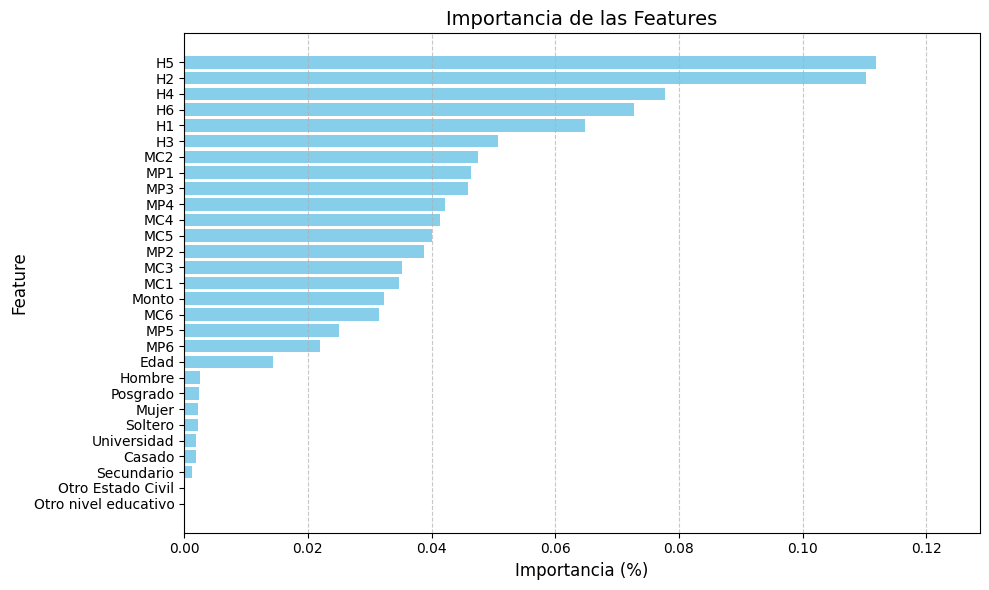

In [ ]:
# Ordenar el DataFrame por importancia
df = feature_importance_df.sort_values(by='importance', ascending=True)

# Crear el gráfico de barras horizontales
plt.figure(figsize=(10, 6)) # Ajusta el tamaño de la figura (ancho, alto)

plt.barh(df['feature'], df['importance'], color='skyblue')

# Añadir etiquetas y título
plt.xlabel('Importancia (%)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Importancia de las Features', fontsize=14)

# Ajustar los límites del eje X si es necesario
plt.xlim(0, max(df['importance']) * 1.15)

# Mejorar el diseño
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

## **STREAMLIT**

LINK DE STREAMLIT: https://taiwan-big-data-app-itapp2x9fdrmeen2w3itqft.streamlit.app/